# Лабораторная работа 4 — Визуализация данных

**Дисциплина:** Машинное обучение  
**Датасет:** GTZAN Genre Collection (features_30_sec.csv)  
**Библиотеки:** Matplotlib, Seaborn, Plotly, Pandas

## Цель работы

Освоить основные инструменты визуализации данных в Python — библиотеки Matplotlib, Seaborn и Plotly — и применить их для разведочного анализа (EDA) аудиодатасета GTZAN.

## Теоретическое введение

### Разведочный анализ данных (EDA)

**Разведочный анализ данных** (Exploratory Data Analysis, EDA) — это подход к анализу наборов данных, целью которого является выявление основных характеристик данных, обнаружение закономерностей, аномалий и проверка предположений с помощью статистических методов и визуализации. EDA является обязательным этапом любого проекта в области машинного обучения и data science.

Основные цели EDA:
- **Понимание структуры данных** — типы переменных, размерность, наличие пропусков
- **Выявление аномалий и выбросов** — значения, значительно отклоняющиеся от основной массы данных
- **Идентификация связей и корреляций** — взаимозависимости между признаками
- **Подготовка данных** — формирование гипотез для дальнейшего моделирования

### Типы визуализаций и их назначение

| Тип графика | Назначение | Когда использовать |
|------------|-----------|--------------------|
| **Scatter plot** | Отображение связи между двумя переменными | Поиск корреляций, кластеров |
| **Гистограмма** | Распределение одной переменной | Оценка формы распределения, модальности |
| **Box plot** | Статистическое описание + выбросы | Сравнение распределений между группами |
| **Heatmap** | Матрица зависимостей | Корреляционный анализ всех пар признаков |
| **Violin plot** | Распределение + плотность | Более детальное сравнение групп, чем box plot |
| **Pair plot** | Все парные зависимости | Обзорный анализ небольшого числа признаков |
| **Bar chart** | Сравнение категорий | Средние значения, частоты по группам |
| **Pie chart** | Доли целого | Пропорции категорий в датасете |

### Библиотеки визуализации в Python

**Matplotlib** — базовая библиотека визуализации. Основана на концепции объектов Figure (полотно) и Axes (области рисования). Предоставляет полный контроль над каждым элементом графика, но требует больше кода для красивого оформления.

**Seaborn** — высокоуровневая надстройка над Matplotlib. Предоставляет удобные функции для статистической визуализации: heatmap, pairplot, violinplot, displot. Автоматически применяет эстетичные стили.

**Plotly** — библиотека для создания интерактивных графиков. Графики поддерживают hover-подсказки, масштабирование, панорамирование. Особенно полезна для презентаций и дашбордов.

### Корреляция и тепловая карта

**Коэффициент корреляции Пирсона** измеряет линейную зависимость между двумя переменными. Значения от -1 (полная отрицательная корреляция) до +1 (полная положительная корреляция), 0 — отсутствие линейной связи. Тепловая карта корреляционной матрицы позволяет визуально обнаружить сильно и слабо связанные признаки.

### Выбросы и метод IQR

**Выброс** — наблюдение, значительно отличающееся от остальных данных. Для обнаружения выбросов используется **метод межквартильного размаха (IQR)**:
- $IQR = Q_3 - Q_1$
- Нижняя граница: $Q_1 - 1.5 \cdot IQR$
- Верхняя граница: $Q_3 + 1.5 \cdot IQR$

Значения за пределами этих границ считаются выбросами и отображаются на boxplot отдельными точками.

## Загрузка и описание данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('Библиотеки загружены')

Библиотеки загружены


In [2]:
df = pd.read_csv('../datasets/gtzan/features_30_sec.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 1000 строк, 60 столбцов


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 1000 non-null   str    
 1   length                   1000 non-null   int64  
 2   chroma_stft_mean         1000 non-null   float64
 3   chroma_stft_var          1000 non-null   float64
 4   rms_mean                 1000 non-null   float64
 5   rms_var                  1000 non-null   float64
 6   spectral_centroid_mean   1000 non-null   float64
 7   spectral_centroid_var    1000 non-null   float64
 8   spectral_bandwidth_mean  1000 non-null   float64
 9   spectral_bandwidth_var   1000 non-null   float64
 10  rolloff_mean             1000 non-null   float64
 11  rolloff_var              1000 non-null   float64
 12  zero_crossing_rate_mean  1000 non-null   float64
 13  zero_crossing_rate_var   1000 non-null   float64
 14  harmony_mean             1000 non-nu

In [4]:
# Числовые признаки (исключаем filename и label)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('length')  # length одинаковый для всех, неинформативен
print(f'Числовых признаков для анализа: {len(numeric_cols)}')
df[numeric_cols].describe().round(3)

Числовых признаков для анализа: 57


,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,...,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,0.379,0.086,0.131,0.003,2201.781,469691.575,2242.541,137079.155,4571.549,1844345.043,...,1.148,60.731,-3.966,62.634,0.508,63.713,-2.329,66.232,-1.095,70.126
std,0.082,0.008,0.066,0.004,715.961,400899.517,526.316,96455.666,1574.792,1425084.588,...,4.579,33.782,4.550,33.479,3.869,34.402,3.756,37.175,3.837,45.229
min,0.172,0.045,0.005,0.000,570.040,7911.251,898.066,10787.185,749.141,14686.119,...,-15.694,9.169,-17.235,13.932,-11.964,15.421,-18.502,13.488,-19.930,7.957
25%,0.320,0.082,0.087,0.001,1627.697,184350.530,1907.241,67376.554,3380.070,772731.231,...,-1.863,40.376,-7.207,40.831,-2.007,41.884,-4.663,41.710,-3.369,42.373
50%,0.383,0.087,0.122,0.002,2209.263,338486.153,2221.393,111977.548,4658.524,1476114.872,...,1.213,52.325,-4.066,54.718,0.670,54.805,-2.394,57.423,-1.166,59.186
75%,0.436,0.091,0.176,0.004,2691.295,612147.935,2578.470,182371.577,5533.810,2555261.803,...,4.360,71.692,-0.839,75.041,3.119,75.386,0.151,78.626,1.313,85.375
max,0.664,0.108,0.398,0.028,4435.244,3036843.062,3509.646,694784.812,8677.673,8660900.484,...,13.457,392.932,11.483,406.059,15.388,332.905,14.695,393.162,15.370,506.065


Датасет GTZAN содержит 1000 аудиозаписей 10 музыкальных жанров (по 100 записей на жанр). Для каждой записи извлечены 57 числовых аудиопризнаков: хроматограммы, спектральные характеристики, MFCC-коэффициенты и другие.

---
## 1. Визуализация с помощью Matplotlib

Matplotlib — это фундаментальная библиотека визуализации в Python. Она основана на иерархии объектов: **Figure** (полотно) содержит один или несколько объектов **Axes** (области рисования), каждый из которых имеет оси, заголовок, легенду и графические элементы.

### 1.1. Scatter plot — зависимость спектральных признаков

Диаграмма рассеяния позволяет визуально оценить связь между двумя числовыми переменными. Построим scatter plot для spectral_centroid_mean и rolloff_mean — оба характеризуют «яркость» звука, и мы ожидаем увидеть положительную корреляцию.

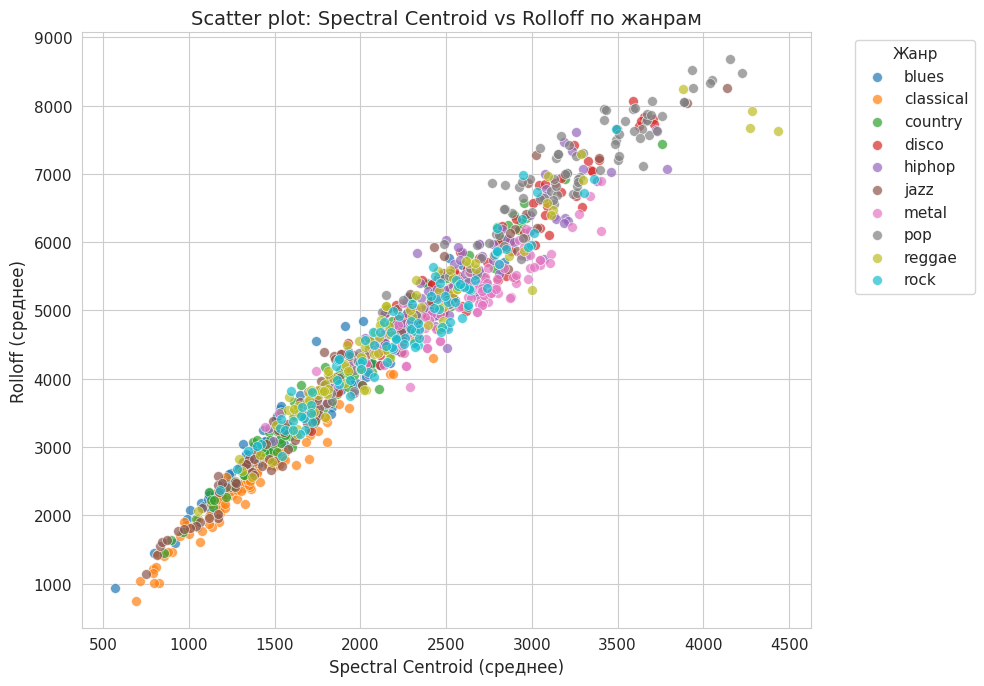

In [5]:
genres = df['label'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(genres)))
genre_colors = dict(zip(genres, colors))

fig, ax = plt.subplots(figsize=(10, 7))

for genre in genres:
    subset = df[df['label'] == genre]
    ax.scatter(
        subset['spectral_centroid_mean'],
        subset['rolloff_mean'],
        c=[genre_colors[genre]],
        label=genre,
        alpha=0.7,
        edgecolors='white',
        linewidth=0.5,
        s=50
    )

ax.set_xlabel('Spectral Centroid (среднее)', fontsize=12)
ax.set_ylabel('Rolloff (среднее)', fontsize=12)
ax.set_title('Scatter plot: Spectral Centroid vs Rolloff по жанрам', fontsize=14)
ax.legend(title='Жанр', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Интерпретация:** Наблюдается сильная положительная корреляция между spectral centroid и rolloff — чем выше спектральный центроид, тем выше частота среза. Жанры metal и rock группируются в правой верхней части (высокая «яркость» звука), тогда как classical занимает нижний левый угол (мягкий, тёмный тембр).

### 1.2. Столбчатая диаграмма средних значений признаков по жанрам

Построим сгруппированную столбчатую диаграмму средних значений ключевых аудиопризнаков по жанрам, чтобы увидеть, какие признаки лучше всего различают жанры.

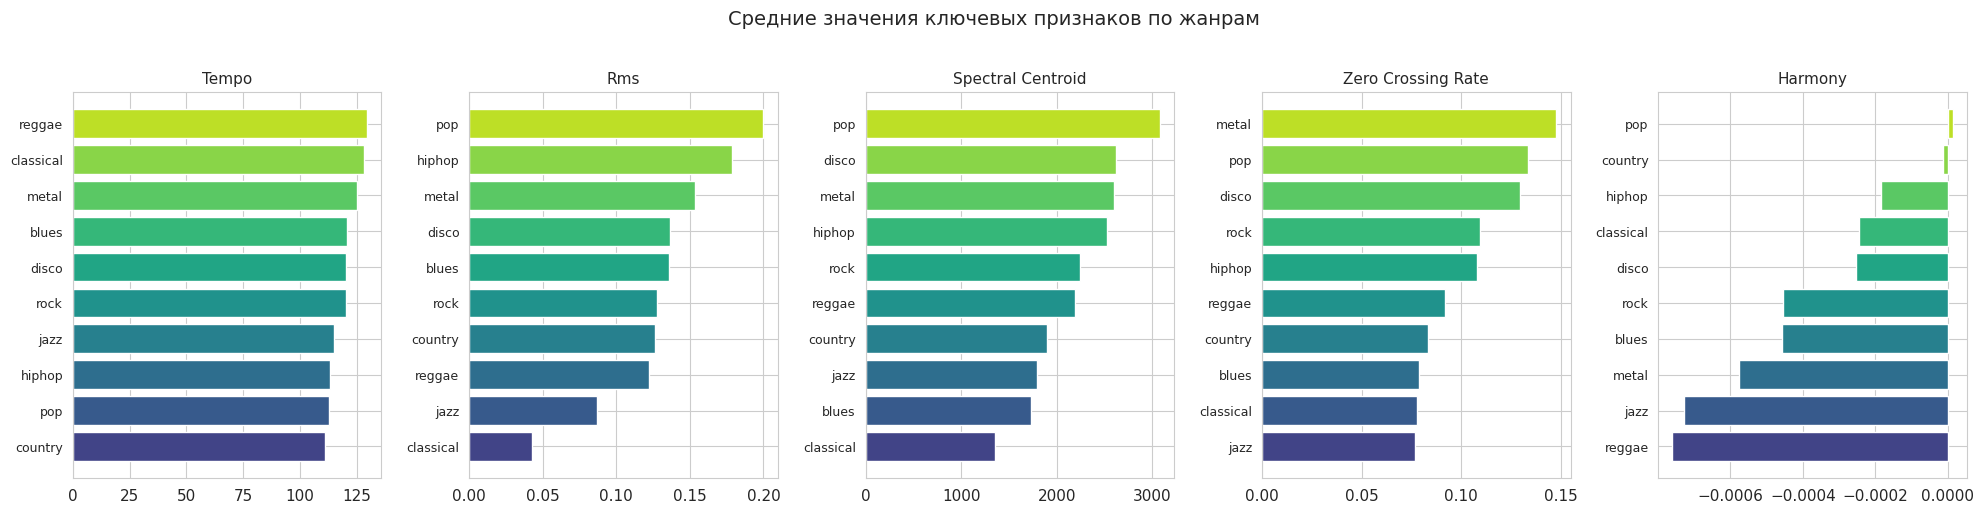

In [6]:
key_features = ['tempo', 'rms_mean', 'spectral_centroid_mean',
                'zero_crossing_rate_mean', 'harmony_mean']

means = df.groupby('label')[key_features].mean()

fig, axes = plt.subplots(1, len(key_features), figsize=(20, 5))

for i, feat in enumerate(key_features):
    sorted_means = means[feat].sort_values(ascending=True)
    bars = axes[i].barh(sorted_means.index, sorted_means.values, color=plt.cm.viridis(
        np.linspace(0.2, 0.9, len(sorted_means))))
    axes[i].set_title(feat.replace('_mean', '').replace('_', ' ').title(), fontsize=11)
    axes[i].tick_params(axis='y', labelsize=9)

fig.suptitle('Средние значения ключевых признаков по жанрам', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Интерпретация:** Каждый признак по-разному разделяет жанры. Например, tempo выше всего у metal и disco, RMS (громкость) максимальна у metal и rock, а harmony более выражена у classical и jazz.

### 1.3. Визуализация матрицы признаков (imshow)

Функция `imshow()` позволяет отображать двумерные данные в виде цветовой матрицы. Визуализируем средние значения всех признаков по жанрам — это даёт общую «карту» различий между жанрами.

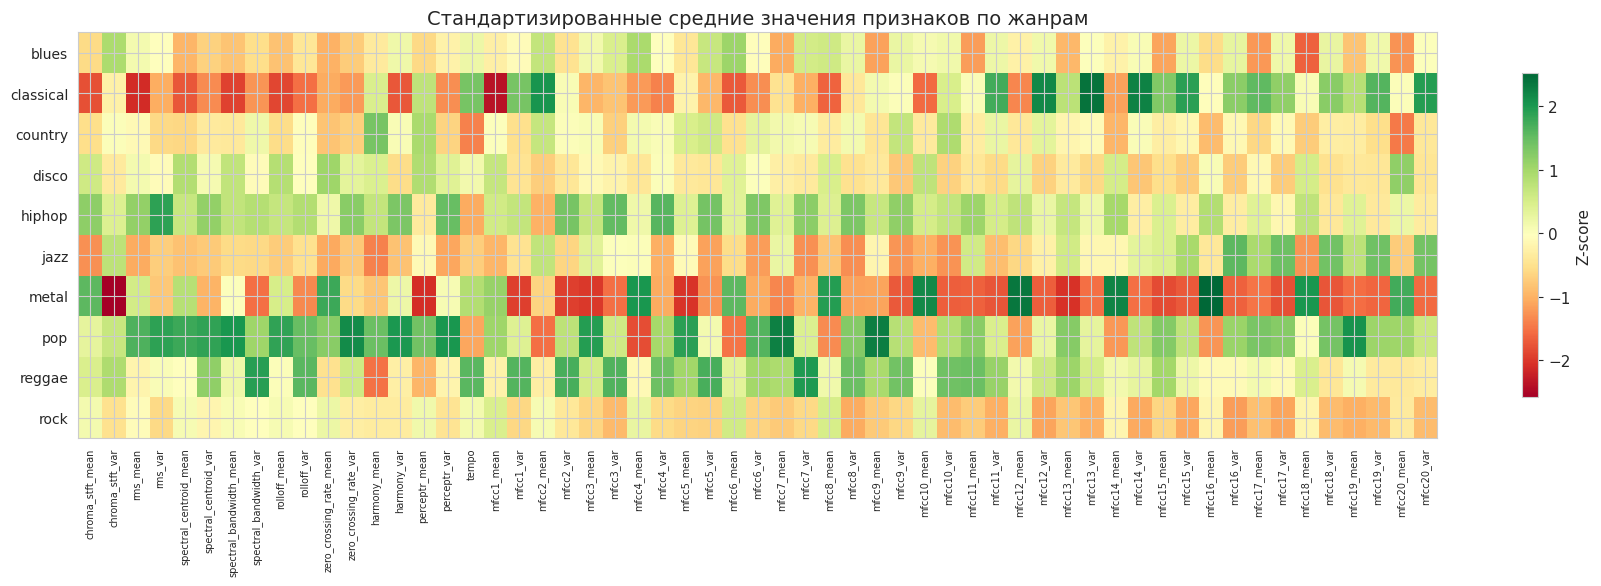

In [7]:
from sklearn.preprocessing import StandardScaler

genre_means = df.groupby('label')[numeric_cols].mean()

# Стандартизируем для сопоставимости масштабов
scaler = StandardScaler()
genre_means_scaled = pd.DataFrame(
    scaler.fit_transform(genre_means),
    index=genre_means.index,
    columns=genre_means.columns
)

fig, ax = plt.subplots(figsize=(18, 6))
im = ax.imshow(genre_means_scaled.values, cmap='RdYlGn', aspect='auto')

ax.set_yticks(range(len(genre_means_scaled.index)))
ax.set_yticklabels(genre_means_scaled.index, fontsize=10)
ax.set_xticks(range(len(genre_means_scaled.columns)))
ax.set_xticklabels(genre_means_scaled.columns, rotation=90, fontsize=7)
ax.set_title('Стандартизированные средние значения признаков по жанрам', fontsize=14)

plt.colorbar(im, ax=ax, shrink=0.8, label='Z-score')
plt.tight_layout()
plt.show()

**Интерпретация:** Матрица наглядно показывает «профили» жанров. Classical выделяется высокими значениями harmony и низкими spectral_centroid/rolloff. Metal, напротив, имеет высокие значения спектральных характеристик и RMS.

---
## 2. Гистограммы распределений по всем признакам

Гистограмма показывает, сколько наблюдений попадает в каждый интервал значений. Это основной инструмент для оценки формы распределения: нормальное, скошенное, бимодальное и т.д. Наложение кривой KDE (Kernel Density Estimation) позволяет увидеть сглаженную оценку плотности.

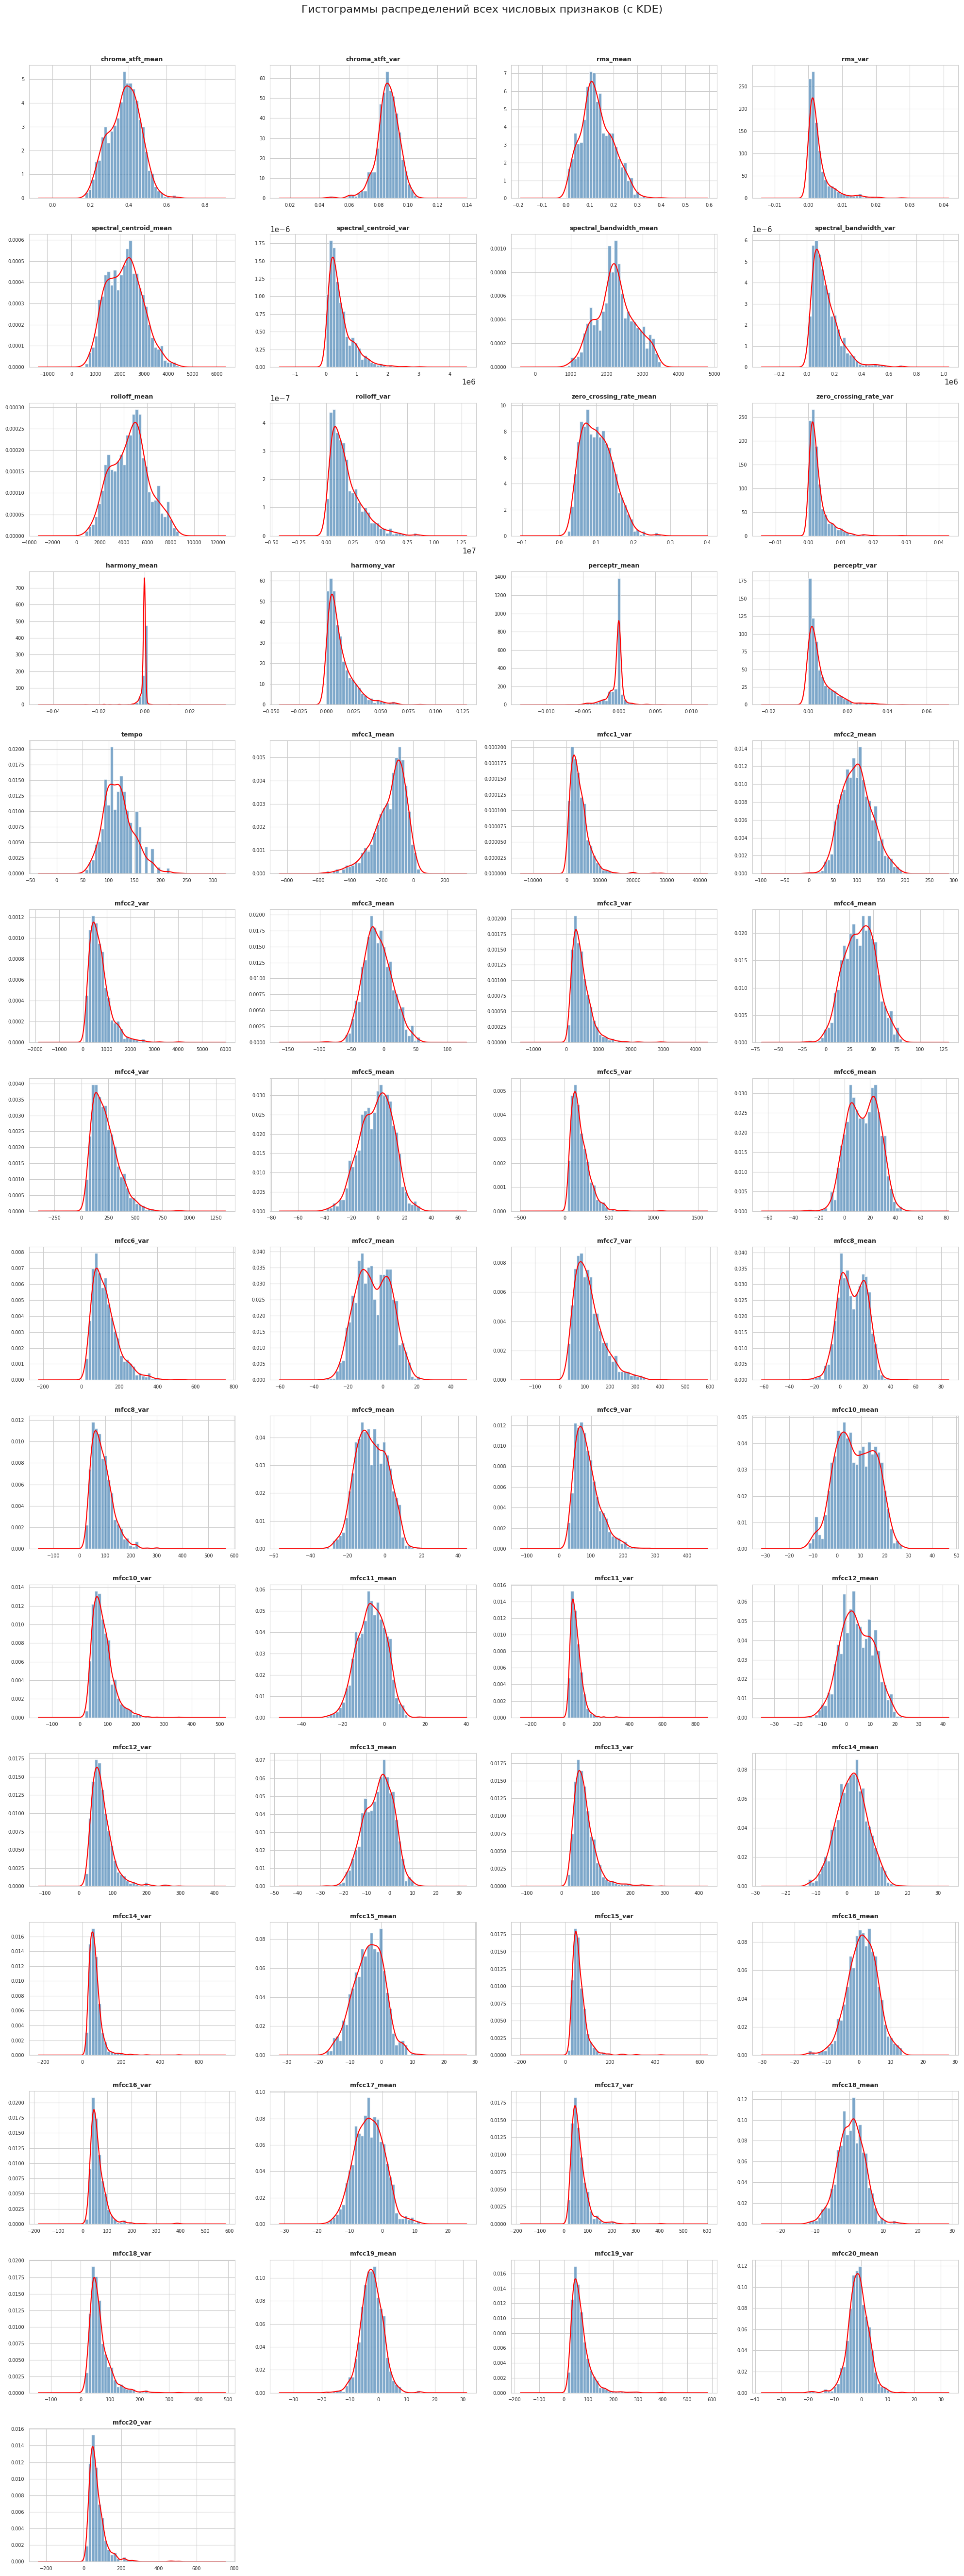

In [8]:
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white',
            alpha=0.7, density=True)
    df[col].plot.kde(ax=ax, color='red', linewidth=1.5)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.set_ylabel('')

# Скрыть пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Гистограммы распределений всех числовых признаков (с KDE)',
             fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**Интерпретация:** Большинство признаков имеют унимодальное распределение, но с различной степенью асимметрии. Например, tempo близок к нормальному распределению, тогда как harmony_mean и perceptr_mean имеют правостороннюю асимметрию. Некоторые MFCC-признаки (mfcc1_mean) демонстрируют бимодальность, что может указывать на различия между группами жанров.

---
## 3. Ящик с усами (Boxplot) для выявления выбросов

**Box plot** (ящик с усами) — один из ключевых инструментов описательной статистики. Он одновременно показывает медиану, межквартильный размах (IQR), «усы» (1.5*IQR от границ ящика) и выбросы (точки за пределами усов). Построим boxplot для ключевых признаков в разбивке по жанрам.

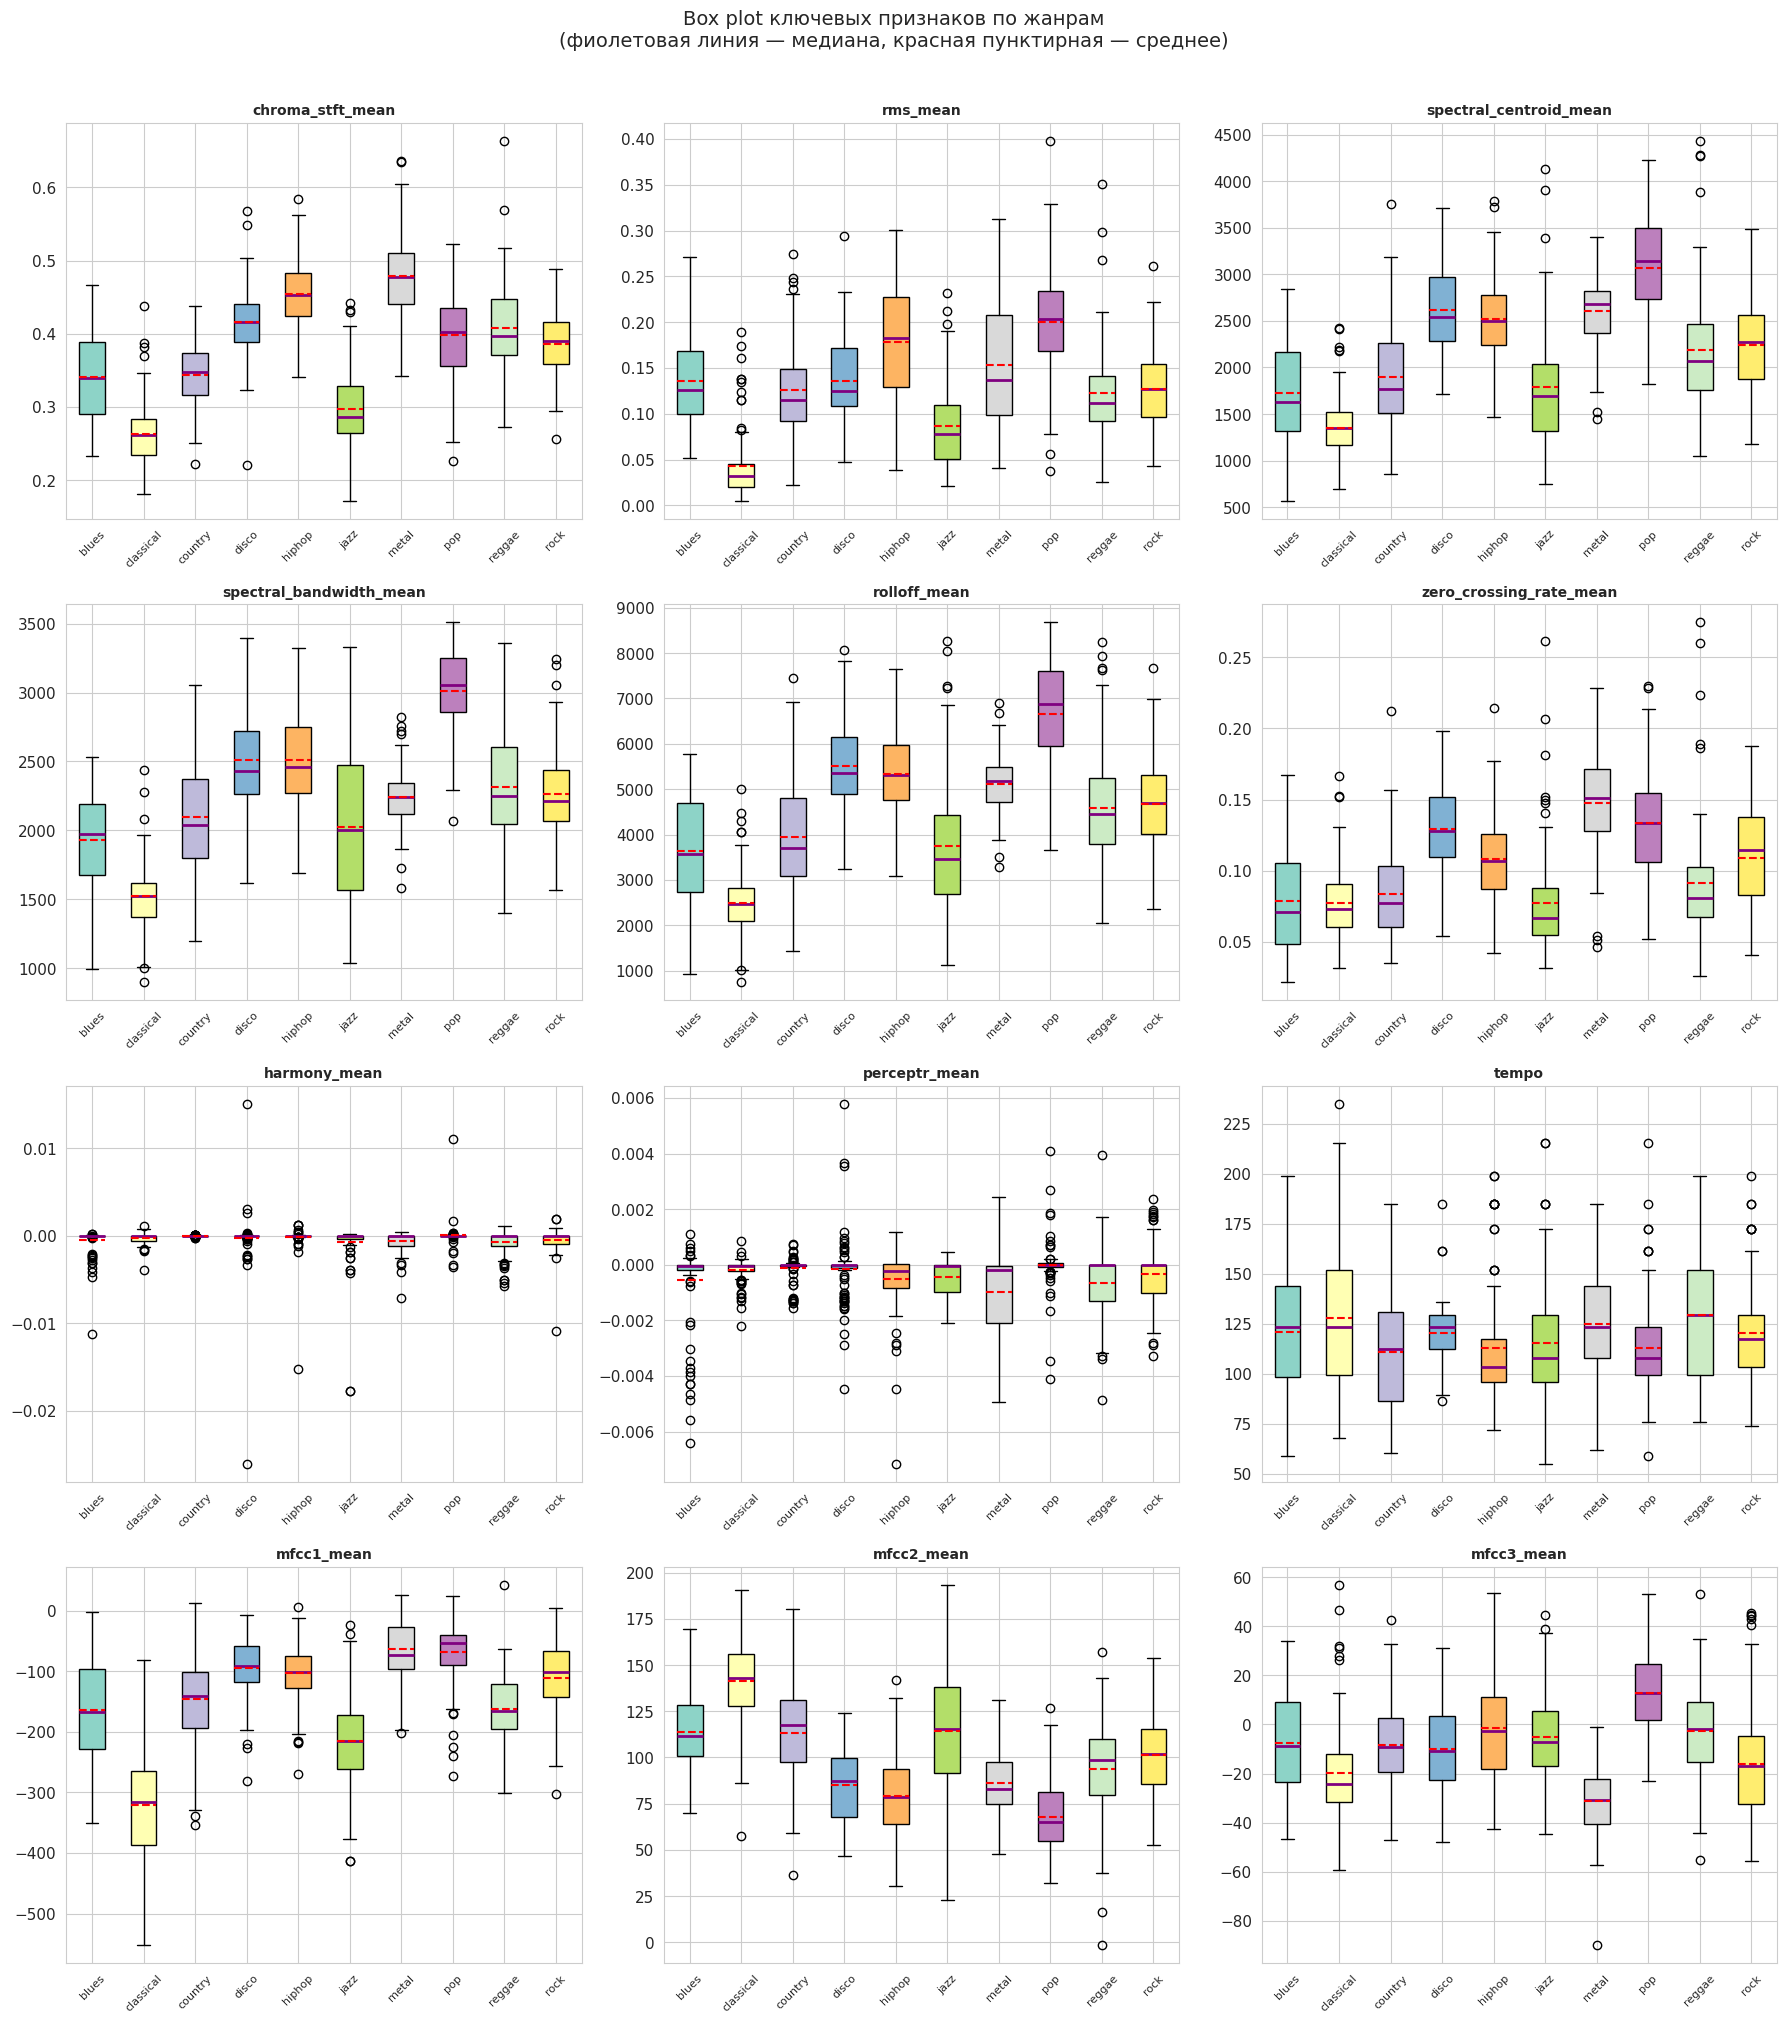

In [9]:
boxplot_features = [
    'chroma_stft_mean', 'rms_mean', 'spectral_centroid_mean',
    'spectral_bandwidth_mean', 'rolloff_mean', 'zero_crossing_rate_mean',
    'harmony_mean', 'perceptr_mean', 'tempo',
    'mfcc1_mean', 'mfcc2_mean', 'mfcc3_mean'
]

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, feat in enumerate(boxplot_features):
    ax = axes[i]
    data_by_genre = [df[df['label'] == g][feat].values for g in sorted(genres)]
    bp = ax.boxplot(data_by_genre, labels=sorted(genres), patch_artist=True,
                    showmeans=True, meanline=True,
                    medianprops={'linewidth': 2, 'color': 'purple'},
                    meanprops={'linewidth': 1.5, 'color': 'red', 'linestyle': '--'})

    palette = plt.cm.Set3(np.linspace(0, 1, len(genres)))
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)

    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

fig.suptitle('Box plot ключевых признаков по жанрам\n'
             '(фиолетовая линия — медиана, красная пунктирная — среднее)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Интерпретация:** Box plot'ы выявляют множество выбросов (точки за пределами усов). Жанр metal выделяется высокими значениями rms_mean, spectral_centroid_mean и rolloff_mean. Classical имеет наибольший разброс в harmony_mean. Tempo содержит выбросы во всех жанрах, так как ритмическая структура произведений внутри одного жанра может существенно различаться.

---
## 4. Тепловая карта корреляций (Seaborn)

Seaborn — высокоуровневая надстройка над Matplotlib, которая упрощает построение статистических графиков. Тепловая карта корреляционной матрицы позволяет одним взглядом оценить, какие признаки сильно связаны друг с другом, а какие — нет.

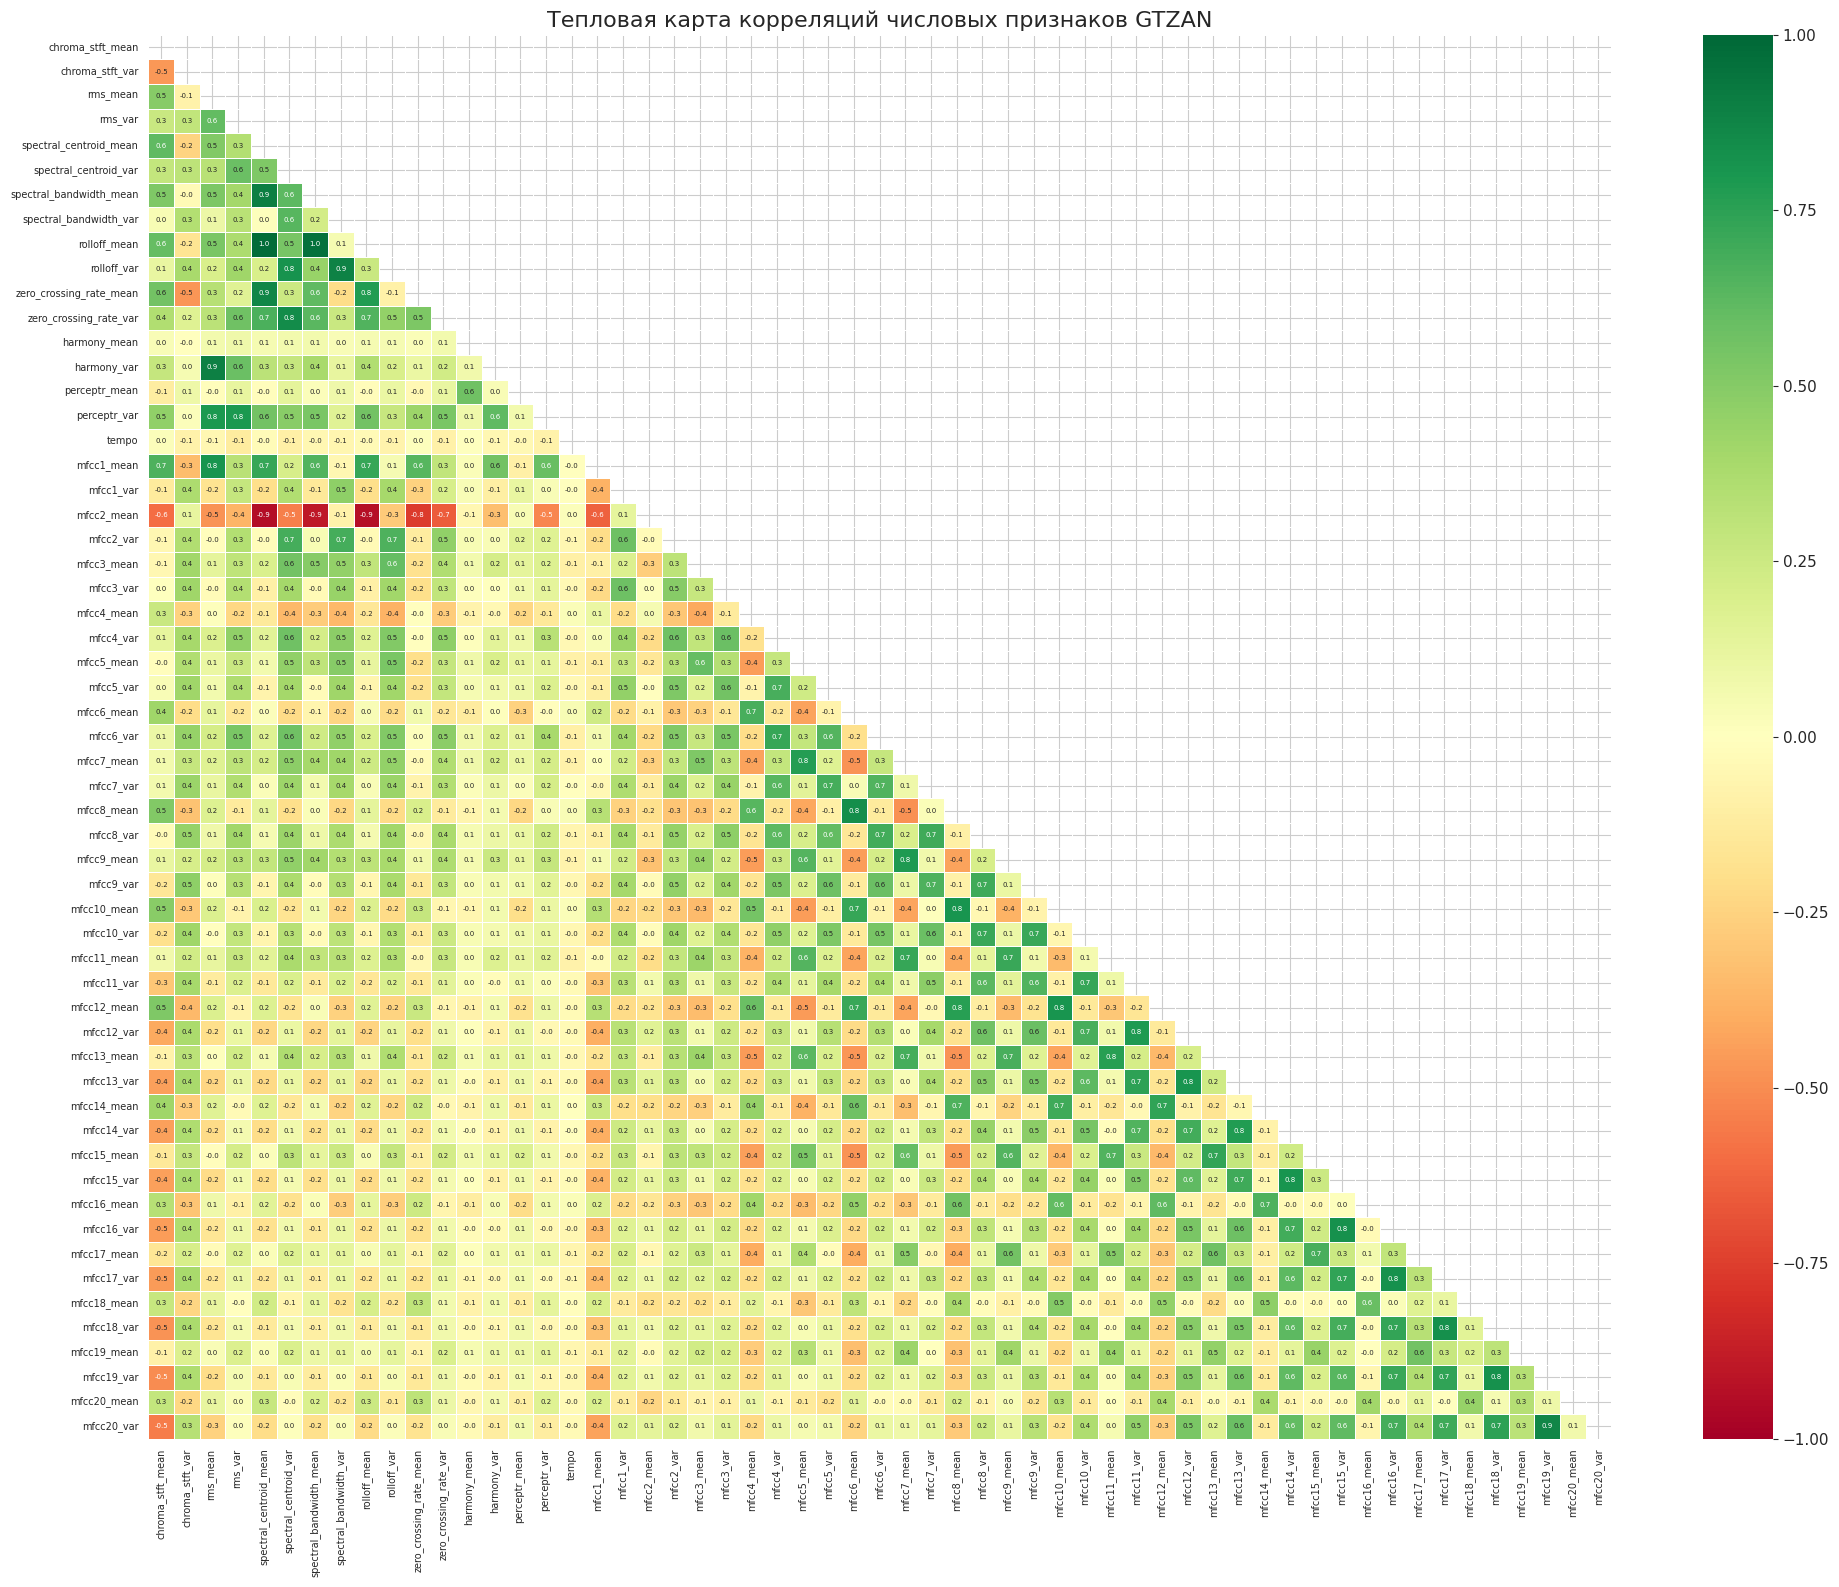

In [10]:
corr_matrix = df[numeric_cols].corr()

# Показываем только нижний треугольник, чтобы избежать дублирования
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 5},
    ax=ax,
    vmin=-1,
    vmax=1
)
ax.set_title('Тепловая карта корреляций числовых признаков GTZAN', fontsize=16)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

### Выводы по корреляционной матрице

Из тепловой карты можно выделить несколько групп сильно скоррелированных признаков:

1. **spectral_centroid_mean, spectral_bandwidth_mean, rolloff_mean** (корреляция > 0.8) — все три описывают «яркость» спектра, что логично.
2. **Пары mean/var** одного и того же признака часто коррелируют, но не всегда — это означает, что дисперсия несёт дополнительную информацию о стабильности признака во времени.
3. **MFCC-признаки** слабо коррелируют друг с другом, что делает их ценными для ML-моделей (меньше мультиколлинеарности).
4. **perceptr_mean и harmony_mean** имеют отрицательную корреляцию — чем выше гармоничность, тем ниже перкуссионная составляющая.

Высококоррелированные признаки (>0.9) могут быть кандидатами на удаление при отборе признаков, чтобы избежать мультиколлинеарности в линейных моделях.

### Топ-10 пар признаков с наибольшей корреляцией

In [11]:
# Извлекаем уникальные пары с наибольшей корреляцией
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Признак 1', 'Признак 2', 'Корреляция']
corr_pairs['|Корреляция|'] = corr_pairs['Корреляция'].abs()
corr_pairs.sort_values('|Корреляция|', ascending=False).head(10).drop(columns='|Корреляция|')

,Признак 1,Признак 2,Корреляция
236,spectral_centroid_mean,rolloff_mean,0.979637
350,spectral_bandwidth_mean,rolloff_mean,0.956189
247,spectral_centroid_mean,mfcc2_mean,-0.940180
475,rolloff_mean,mfcc2_mean,-0.934302
234,spectral_centroid_mean,spectral_bandwidth_mean,0.904435
361,spectral_bandwidth_mean,mfcc2_mean,-0.896652
127,rms_mean,harmony_var,0.893898
408,spectral_bandwidth_var,rolloff_var,0.884877
238,spectral_centroid_mean,zero_crossing_rate_mean,0.874749
3134,mfcc19_var,mfcc20_var,0.868718


---
## 5. Продвинутые визуализации Seaborn

### 5.1. Violin plot — распределения по жанрам

Violin plot сочетает информацию box plot и KDE-оценки плотности. Внутри «скрипки» показана медиана и квартили, а форма отражает плотность распределения на каждом уровне значения.

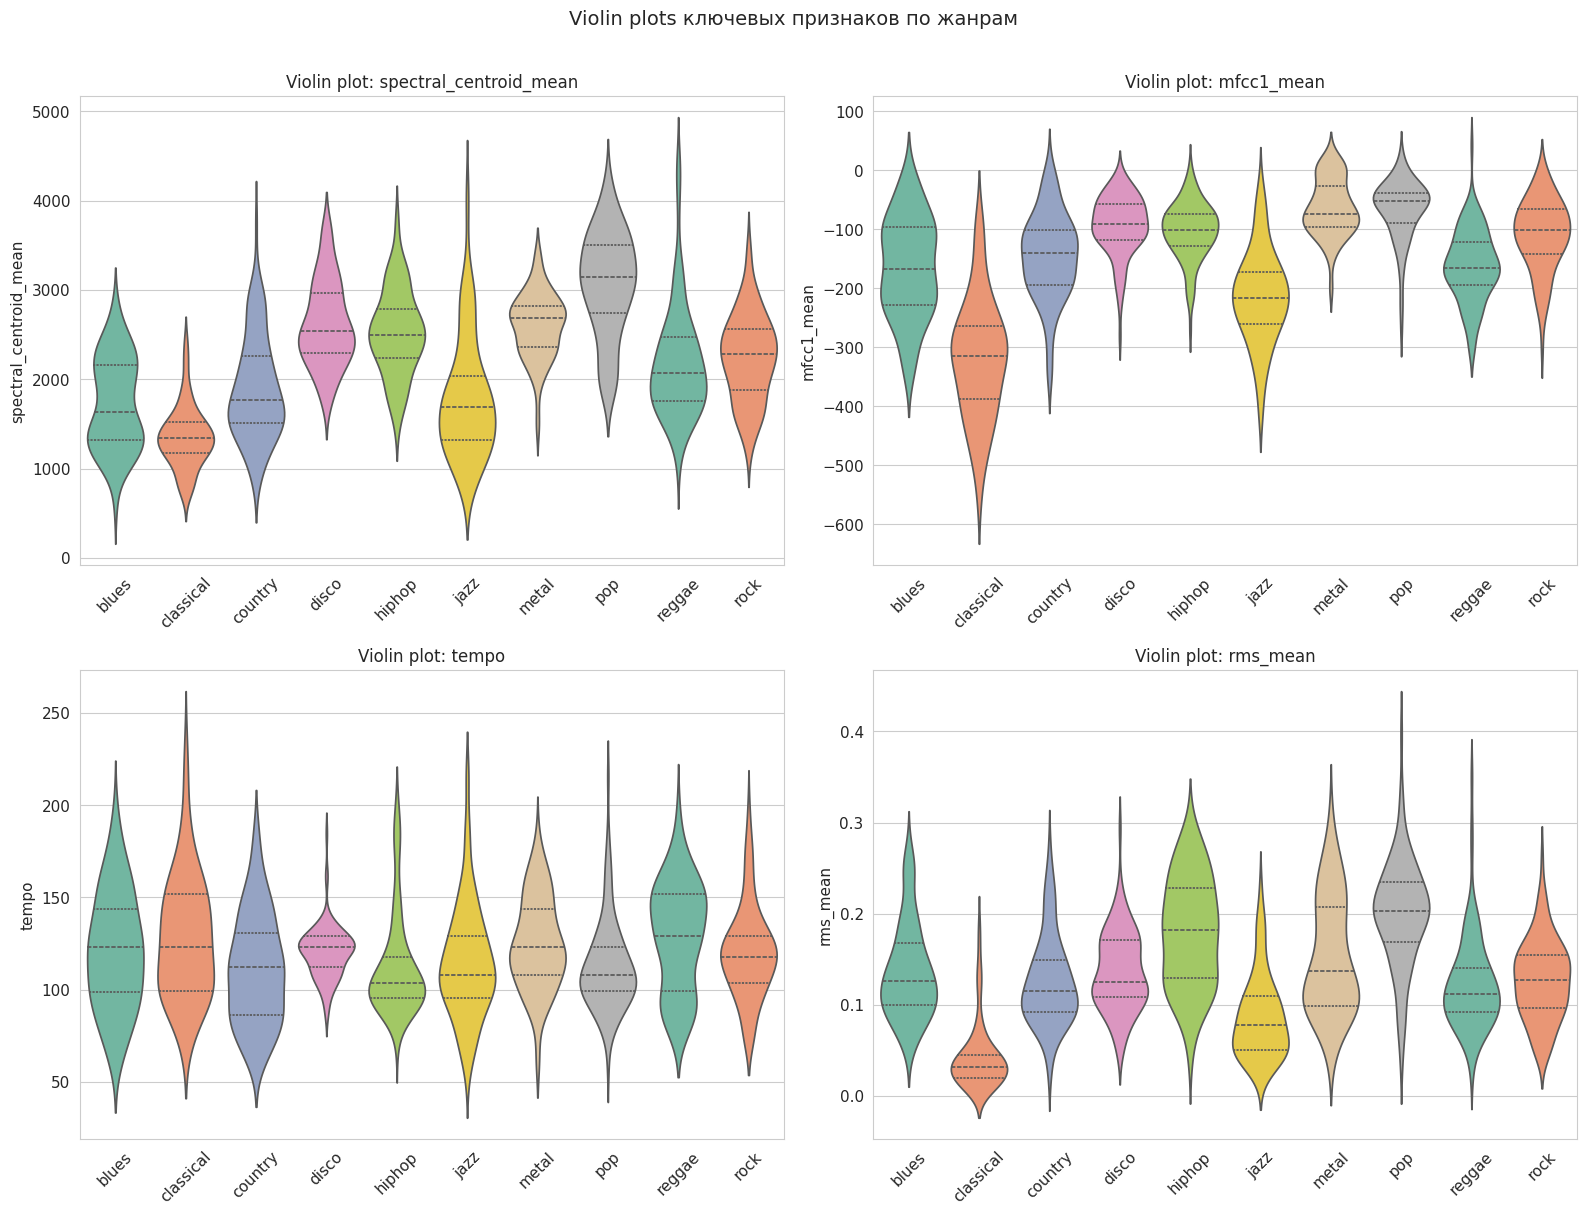

In [12]:
violin_features = ['spectral_centroid_mean', 'mfcc1_mean', 'tempo', 'rms_mean']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(violin_features):
    sns.violinplot(
        data=df, x='label', y=feat,
        palette='Set2', inner='quartile', ax=axes[i]
    )
    axes[i].set_title(f'Violin plot: {feat}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle('Violin plots ключевых признаков по жанрам', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Интерпретация:** Violin plot показывает, что для spectral_centroid_mean classical имеет узкое, компактное распределение в нижнем диапазоне, а metal — широкое в верхнем. MFCC1 демонстрирует чёткое разделение: отрицательные значения у classical и jazz, положительные у hiphop и reggae.

### 5.2. Pair plot — парные зависимости ключевых признаков

Pairplot строит scatter plot для каждой пары признаков и гистограмму для каждого признака на диагонали. Это позволяет одновременно оценить распределения и взаимозависимости.

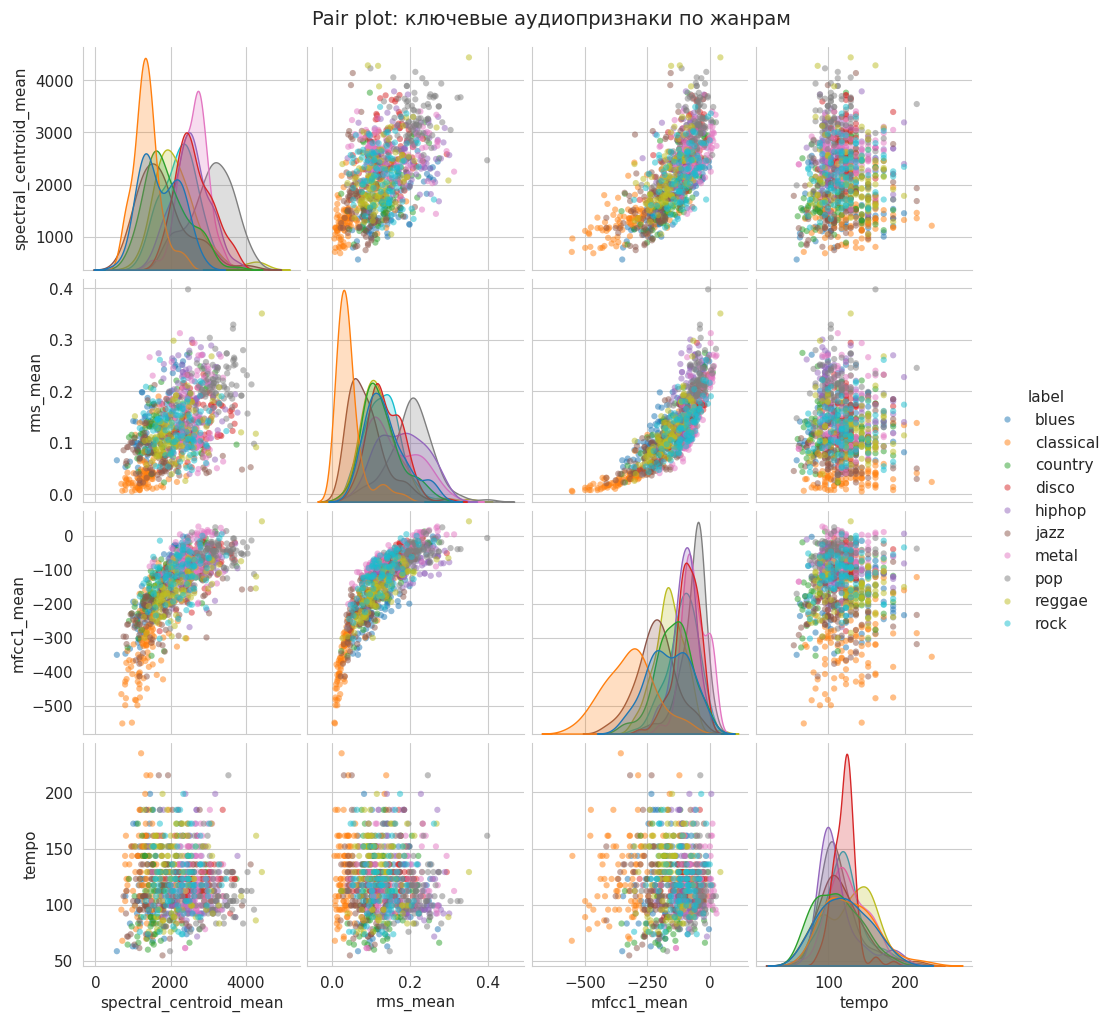

In [13]:
pair_features = ['spectral_centroid_mean', 'rms_mean', 'mfcc1_mean', 'tempo', 'label']

g = sns.pairplot(
    df[pair_features],
    hue='label',
    palette='tab10',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20, 'edgecolor': 'none'},
    height=2.5
)
g.figure.suptitle('Pair plot: ключевые аудиопризнаки по жанрам', y=1.02, fontsize=14)
plt.show()

**Интерпретация:** Pairplot подтверждает, что комбинация spectral_centroid_mean и rms_mean хорошо разделяет жанры metal и classical. MFCC1 также является дискриминативным признаком. Tempo показывает наибольшее перекрытие между жанрами.

---
## 6. Интерактивные визуализации с Plotly

Plotly позволяет создавать интерактивные графики с hover-подсказками, масштабированием и выделением. Это особенно полезно при работе с многомерными данными.

### 6.1. Интерактивный scatter plot

In [14]:
fig = px.scatter(
    df, x='tempo', y='spectral_centroid_mean',
    color='label',
    hover_data=['rms_mean', 'mfcc1_mean', 'filename'],
    title='Интерактивный Scatter: Tempo vs Spectral Centroid',
    labels={
        'tempo': 'Темп (BPM)',
        'spectral_centroid_mean': 'Spectral Centroid (среднее)',
        'label': 'Жанр'
    },
    opacity=0.7
)
fig.update_layout(width=900, height=600)
fig.show()

### 6.2. Столбчатая диаграмма (Bar chart)

In [15]:
genre_counts = df['label'].value_counts().sort_values(ascending=True)

fig = go.Figure(go.Bar(
    x=genre_counts.values,
    y=genre_counts.index,
    orientation='h',
    marker_color=px.colors.qualitative.Set2[:len(genre_counts)],
    text=genre_counts.values,
    textposition='outside'
))

fig.update_layout(
    title='Количество записей по жанрам',
    xaxis_title='Количество',
    yaxis_title='Жанр',
    width=700, height=450
)
fig.show()

### 6.3. Интерактивный Box plot

In [16]:
fig = px.box(
    df, x='label', y='spectral_centroid_mean',
    color='label',
    title='Box plot: Spectral Centroid Mean по жанрам (Plotly)',
    labels={'label': 'Жанр', 'spectral_centroid_mean': 'Spectral Centroid (среднее)'},
    points='outliers'
)
fig.update_layout(width=900, height=500, showlegend=False)
fig.show()

### 6.4. Интерактивная гистограмма

In [17]:
fig = px.histogram(
    df, x='tempo', color='label',
    nbins=40, barmode='overlay',
    opacity=0.6,
    title='Гистограмма: распределение темпа по жанрам',
    labels={'tempo': 'Темп (BPM)', 'label': 'Жанр'}
)
fig.update_layout(width=900, height=500)
fig.show()

### 6.5. Круговая диаграмма (Pie chart)

In [18]:
genre_counts_all = df['label'].value_counts()

fig = go.Figure(go.Pie(
    labels=genre_counts_all.index,
    values=genre_counts_all.values,
    hole=0.3,
    textinfo='label+percent',
    marker=dict(colors=px.colors.qualitative.Set3)
))
fig.update_layout(
    title='Доли жанров в датасете GTZAN',
    width=650, height=500
)
fig.show()

**Интерпретация Plotly-визуализаций:** Датасет GTZAN сбалансирован — каждый жанр представлен 100 записями (по 10%). Интерактивность Plotly позволяет детально исследовать каждую точку данных, что невозможно в статичных графиках Matplotlib.

---
## 7. Визуализация через Pandas .plot()

Метод `.plot()` в Pandas — это обёртка над Matplotlib, позволяющая строить графики прямо из DataFrame/Series. Удобство в том, что не нужно отдельно передавать x и y — Pandas использует индекс и столбцы автоматически.

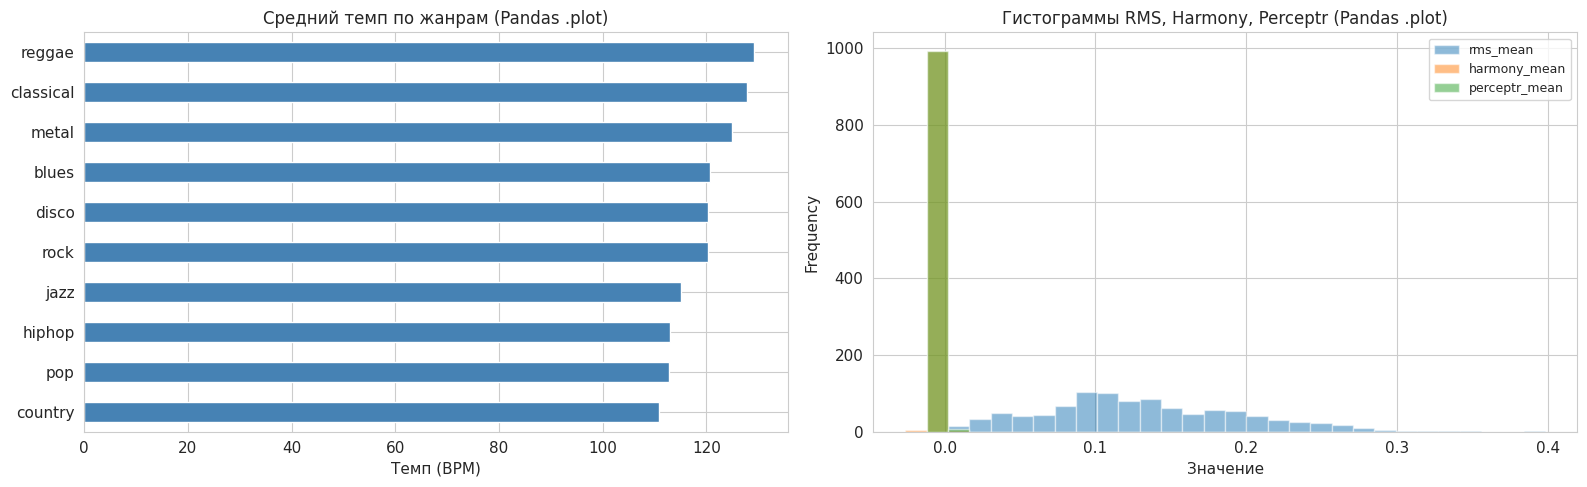

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot через pandas
df.groupby('label')['tempo'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Средний темп по жанрам (Pandas .plot)', fontsize=12)
axes[0].set_xlabel('Темп (BPM)')
axes[0].set_ylabel('')

# Гистограмма через pandas
df[['rms_mean', 'harmony_mean', 'perceptr_mean']].plot(
    kind='hist', bins=30, alpha=0.5, ax=axes[1], edgecolor='white'
)
axes[1].set_title('Гистограммы RMS, Harmony, Perceptr (Pandas .plot)', fontsize=12)
axes[1].set_xlabel('Значение')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Интерпретация:** Pandas .plot() позволяет быстро строить графики с минимумом кода. Метод удобен для экспресс-анализа, но для тонкой настройки оформления всё равно потребуется Matplotlib API.

---
## Выводы

В ходе лабораторной работы мы освоили три основных инструмента визуализации данных в Python и применили их к аудиодатасету GTZAN:

### Основные результаты:

1. **Matplotlib** предоставляет полный контроль над каждым элементом графика. Мы построили scatter plot, столбчатые диаграммы и матричные визуализации (imshow), которые показали чёткие различия между жанрами по спектральным признакам.

2. **Гистограммы** распределений выявили, что большинство аудиопризнаков имеют унимодальное распределение различной степени асимметрии, а некоторые MFCC-коэффициенты демонстрируют бимодальность.

3. **Box plot'ы** позволили обнаружить выбросы во всех признаках, а также показали, что такие жанры как metal и classical наиболее «отделимы» от остальных по спектральным характеристикам.

4. **Тепловая карта корреляций** (Seaborn) выявила группы высококоррелированных признаков (spectral_centroid, rolloff, bandwidth), что важно для последующего отбора признаков.

5. **Violin plot и pairplot** (Seaborn) дали более детальное представление о распределениях внутри жанров и подтвердили, что комбинация spectral_centroid + rms + mfcc1 хорошо разделяет жанры.

6. **Plotly** обеспечил интерактивность: hover-подсказки с информацией о каждой записи, масштабирование и выделение отдельных жанров.

7. **Pandas .plot()** продемонстрировал удобный способ быстрого построения графиков прямо из DataFrame.

### Практическое значение:

Проведённый визуальный анализ сформировал понимание структуры данных и выявил признаки, наиболее полезные для задачи классификации жанров. Это станет основой для последующих лабораторных работ по отбору признаков и обучению моделей.